# 4. Clasificación binaria y perceptrón

**Objetivo.** Comprender cómo una combinación lineal define una frontera de decisión y entrenar el perceptrón clásico.

Para $x\in\mathbb{R}^d$, calculamos $z=w^Tx+b$. El perceptrón asigna clase 1 si $z\geq0$ y clase 0 en caso contrario. La ecuación $w^Tx+b=0$ define la frontera.

In [1]:
import random
import torch
import matplotlib.pyplot as plt

SEMILLA = 42
random.seed(SEMILLA)
torch.manual_seed(SEMILLA)
torch.set_printoptions(precision=3, sci_mode=False)
print(f"PyTorch {torch.__version__} · semilla {SEMILLA}")

PyTorch 2.14.0 · semilla 42


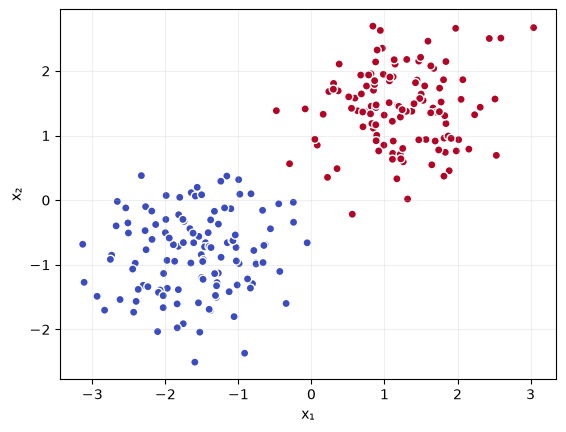

In [2]:
n = 120
clase_0 = torch.randn(n, 2) * 0.65 + torch.tensor([-1.5, -1.0])
clase_1 = torch.randn(n, 2) * 0.65 + torch.tensor([1.2, 1.4])
X = torch.cat([clase_0, clase_1])
y = torch.cat([torch.zeros(n), torch.ones(n)])
plt.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", edgecolor="white", s=35)
plt.xlabel("x₁"); plt.ylabel("x₂"); plt.grid(alpha=.2);
plt.savefig("imagenes/datos_clasificacion.png", dpi=160, bbox_inches="tight")
plt.show()

## Regla de aprendizaje

Ante una predicción incorrecta actualizamos

$$w\leftarrow w+\eta(y-\hat y)x,\qquad b\leftarrow b+\eta(y-\hat y).$$

Si los datos son linealmente separables, el algoritmo converge a alguna frontera que los separa.

In [3]:
w = torch.zeros(2)
b = torch.tensor(0.0)
errores = []
for epoca in range(15):
    fallos = 0
    for i in torch.randperm(len(X)):
        pred = (X[i] @ w + b >= 0).float()
        error = y[i] - pred
        if error != 0:
            w += 0.1 * error * X[i]
            b += 0.1 * error
            fallos += 1
    errores.append(fallos)

predicciones = (X @ w + b >= 0).float()
print("w:", w, "b:", b.item())
print("exactitud:", (predicciones == y).float().mean().item())
print("errores por época:", errores)

w: tensor([0.180, 0.150]) b: 0.0
exactitud: 1.0
errores por época: [4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


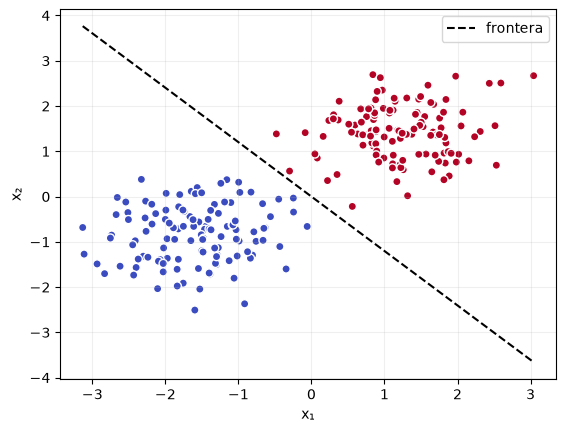

In [4]:
plt.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", edgecolor="white", s=35)
xs = torch.linspace(X[:, 0].min(), X[:, 0].max(), 100)
ys = -(w[0] * xs + b) / w[1]
plt.plot(xs, ys, "k--", label="frontera")
plt.xlabel("x₁"); plt.ylabel("x₂"); plt.legend(); plt.grid(alpha=.2);
plt.savefig("imagenes/frontera_perceptron.png", dpi=160, bbox_inches="tight")
plt.show()

## El límite del perceptrón: XOR

XOR no puede separarse con una única recta. No es un fallo de entrenamiento, sino una limitación de la familia de modelos.

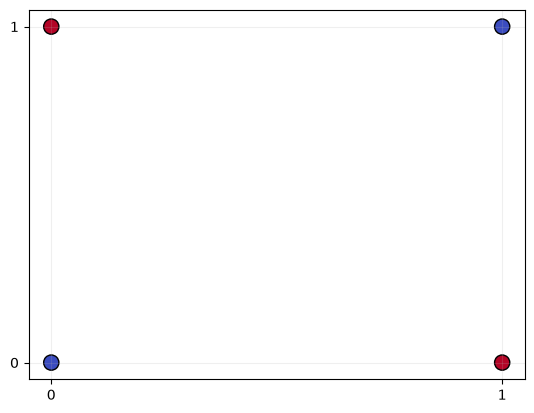

In [5]:
X_xor = torch.tensor([[0., 0.], [0., 1.], [1., 0.], [1., 1.]])
y_xor = torch.tensor([0., 1., 1., 0.])
plt.scatter(X_xor[:, 0], X_xor[:, 1], c=y_xor, cmap="coolwarm", s=120, edgecolor="black")
plt.xticks([0, 1]); plt.yticks([0, 1]); plt.grid(alpha=.2);
plt.savefig("imagenes/problema_xor.png", dpi=160, bbox_inches="tight")
plt.show()

## Preguntas

1. ¿Qué representa la dirección de $w$?
2. Añade ruido hasta que las clases se solapen. ¿Qué ocurre con los errores?
3. Intenta dibujar una recta que resuelva XOR. ¿Qué pieza arquitectónica falta?

**Idea clave:** una neurona lineal solo crea una frontera lineal; combinar neuronas permite fronteras no lineales.